# Running nicheVI

In [2]:
%load_ext autoreload
%autoreload 2

In [32]:
import anndata as ad
import numpy as np
import pandas as pd
from anndata import AnnData

from rich import print
import os

import scvi
import nichevi

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.sparse import csr_matrix

from scib_metrics.benchmark import Benchmarker, BatchCorrection, BioConservation

scvi.settings.seed = 34

Global seed set to 34


In [4]:
from dataclasses import dataclass
from typing import Optional


@dataclass(frozen=True)
class PARAMS:
    "set all params for our analysis"

    # DATA_FOLDER: str = (
    #     "/home/labs/nyosef/Collaboration/SpatialDatasets/xenium/human_breast_cancer/"
    # )
    DATA_FOLDER: str = "/home/nathanlevy/Data/"

    # DATA_FILE: str = "xenium_breast_cancer_S1_R1_2.h5ad"
    DATA_FILE: str = "adata_M1_M2_core_6_sections.h5ad"

    # for the data
    COORDS: str = "spatial"
    BATCH: str = "brain_section_label"
    SAMPLE: str = "brain_section_label"
    CELL_TYPE: str = "cell_type"
    NICHE: str = "major_brain_region"

    # for scVI
    N_LAYERS: int = 1
    N_LATENT: int = 10
    LIKELIHOOD: str = "poisson"
    ######################
    N_EPOCHS_SCVI: int = 400
    BATCH_SIZE: int = 128
    OPTIMIZER: str = "Adam"
    ######################
    WEIGHT_DECAY: float = 1e-6
    KL_WARMUP: Optional[int] = None

    # for nicheVI
    K_NN: int = 20  # TODO try also less cells per niche, like 12
    N_LAYERS_NICHE: int = 1
    N_LAYERS_COMPO: int = 1
    N_HIDDEN: int = 128
    N_HIDDEN_COMPO: int = 128  # TODO make it adaptable
    N_HIDDEN_NICHE: int = 128
    N_LATENT_NICHEVI: int = 10
    ATTENTION_DECODER: bool = True
    N_HEADS: int = 2
    ######################
    N_EPOCHS_NICHEVI: int = 400
    REDUCE_LR_ON_PLATEAU: bool = True
    LR: float = 1e-4
    SPATIAL_WARMUP: Optional[int] = 10
    MIN_SPATIAL_WEIGHT: float = 1.0
    MAX_SPATIAL_WEIGHT: float = 10

    # +batch norm/layer norm

    CELL_TYPES_FOR_NICHES = None

    CELL_TYPES_FOR_STRATIFICATION = [
        # "DCIS_2",
        "Macrophages_1",
        # "Unlabeled",
        # "Invasive_Tumor",
        # "Stromal",
        # "DCIS_1",
        # "Myoepi_ACTA2+",
        "CD8+_T_Cells",
        # "Endothelial",
        # "Prolif_Invasive_Tumor",
        # "T_Cell_&_Tumor_Hybrid",
        # "Mast_Cells",
        "CD4+_T_Cells",
        "B_Cells",
        "Macrophages_2",
        # "Stromal_&_T_Cell_Hybrid",
        # "Perivascular-Like",
        "LAMP3+_DCs",  # PUT THE DCS TOGETHER
        "IRF7+_DCs",
        # "Myoepi_KRT15+",
    ]


setup = PARAMS()

In [5]:
data_dir, data_file = setup.DATA_FOLDER, setup.DATA_FILE

data_file_name = os.path.splitext(data_file)[0]
print(data_file_name)

path_to_save = os.path.join("../niche-VI-experiments/checkpoints", data_file_name)
os.makedirs(path_to_save, exist_ok=True)

adata = ad.read_h5ad(os.path.join(data_dir, data_file))
print(adata)

adata_M1_M2_core_6_sections

AnnData object with n_obs × n_vars = 250790 × 1122
    obs: 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 
'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 
'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 
'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 
'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 
'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 
'observation_joinid', 'n_counts', 'batch', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 
'feature_length', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 
'total_counts', 'log1p_total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca', 'simvi_train_mask', 'simvi_train_mask_06', 
'simvi_train_mask_08', 'simvi_val_mask', 'simvi_val_mask_06', 'simvi_val_mask_08'
    obsm: 'X_CCF', 'X_pca', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 
'banksy_pc_20_lambda_0.4', 'banksy_pc_20_lambda_0.5', 'banksy_pc_20_lambda_0.6', 'simvi_both', 'simvi_both_06', 
'simvi_both_07', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_06', 'simvi_both_MDE_07', 'simvi_both_MDE_08', 
'simvi_interact', 'simvi_interact_06', 'simvi_interact_07', 'simvi_interact_08', 'simvi_interact_MDE', 
'simvi_interact_MDE_06', 'simvi_interact_MDE_07', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_06',
'simvi_intrinsic_07', 'simvi_intrinsic_08', 'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_06', 
'simvi_intrinsic_MDE_07', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [6]:
scvi_is_trained = True
nichevi_is_trained = True
save_scvi = True

print("scVI trained: ", scvi_is_trained, "nicheVI trained: ", nichevi_is_trained)


history_setup = {}

if scvi_is_trained == False:
    scvi.model.SCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key=setup.BATCH,
    )

    scvivae = scvi.model.SCVI(
        adata,
        gene_likelihood=setup.LIKELIHOOD,
        n_layers=setup.N_LAYERS,
        n_latent=setup.N_LATENT,
    )

    scvivae.train(
        max_epochs=setup.N_EPOCHS_SCVI,
        train_size=0.8,
        validation_size=0.2,
        batch_size=setup.BATCH_SIZE,
        plan_kwargs=dict(
            n_epochs_kl_warmup=setup.KL_WARMUP,
            weight_decay=setup.WEIGHT_DECAY,
            optimizer=setup.OPTIMIZER,
        ),
        # trainer_kwargs=dict(check_val_every_n_epoch=1),
        early_stopping=True,
    )

    if save_scvi:
        scvivae.save(
            dir_path=path_to_save + "/scvivae_E" + str(setup.N_EPOCHS_SCVI)
            # + "_"
            # + str(setup.N_LAYERS)
            # + "L"
            + ".pt",
            save_anndata=False,
        )

if scvi_is_trained:
    scvivae = scvi.model.SCVI.load(
        dir_path=path_to_save + "/scvivae_E" + str(setup.N_EPOCHS_SCVI) + ".pt",
        adata=adata,
    )

adata.obsm["X_scVI"] = scvivae.get_latent_representation(batch_size=setup.BATCH_SIZE)
# SCVI_MDE_KEY = "X_scVI_MDE"
# adata.obsm[SCVI_MDE_KEY] = scvi.model.utils.mde(adata.obsm["X_scVI"])

# adata.write_h5ad(
#     os.path.join(path_to_save, data_file_name + "_scVI.h5ad"),
# )

history_setup["X_scVI"] = scvivae.history


print("scVI done...")

scVI trained:  True nicheVI trained:  True

INFO     File ../niche-VI-experiments/checkpoints/adata_M1_M2_core_6_sections/scvivae_E400.pt/model.pt already     
         downloaded                                                                                                


scVI done...

In [7]:
from lightning import Trainer
from lightning.pytorch.callbacks import DeviceStatsMonitor

device_stats = DeviceStatsMonitor()
# trainer = Trainer(callbacks=[device_stats])

In [8]:
niche_setup = {
    "scvi_r1_kl1_s10": {
        "cell_rec_weight": 1,
        "latent_kl_weight": 1.0,
        "spatial_weight": 1,
        "n_latent": setup.N_LATENT_NICHEVI,
        "n_layers_niche": setup.N_LAYERS_NICHE,
        "n_layers_compo": setup.N_LAYERS_COMPO,
        "n_hidden_niche": setup.N_HIDDEN_NICHE,
        "n_hidden_compo": setup.N_HIDDEN_COMPO,
        "niche_expression": "scvi",
        "optimizer": setup.OPTIMIZER,
    },
}

In [24]:
for setting in niche_setup.keys():
    print("[bold green]" + setting + "[/bold green]")
    setup_dict = niche_setup[setting]

    # preprocessing function to populate adata.obsm with the keys 'neighborhood_composition',
    # 'qz1_m', 'qz1_var', 'niche_indexes', 'niche_distances', 'qz1_m_niche_knn', 'qz1_var_niche_knn', 'qz1_m_niche_ct',
    # 'qz1_var_niche_ct'

    path_to_save_nichevae = (
        path_to_save
        + "/nichevae_"
        + setting
        + "_"
        + str(setup.N_EPOCHS_NICHEVI)
        + ".pt"
    )

    if setup_dict["niche_expression"] == "poisson_counts":
        NICHE_LIKELIHOOD = "poisson"
        adata.obsm["qz1_m"] = adata.layers["counts"]

    if setup_dict["niche_expression"] == "pca":
        NICHE_LIKELIHOOD = "gaussian"
        adata.obsm["qz1_m"] = adata.obsm["X_pca"]

    if setup_dict["niche_expression"] == "scvi":
        NICHE_LIKELIHOOD = "gaussian"
        adata.obsm["qz1_m"] = adata.obsm["X_scVI"]

    if setup_dict["niche_expression"] == "gaussian_counts":
        NICHE_LIKELIHOOD = "gaussian"
        adata.obsm["qz1_m"] = adata.X.toarray()

    nichevi.nicheSCVI.preprocessing_anndata(
        adata,
        niche_composition_key="neighborhood_composition",
        niche_indexes_key="niche_indexes",
        niche_distances_key="niche_distances",
        niche_type_key="niche_type",
        niche_treshold=None,
        cell_type_for_niches=None,
        label_key=setup.CELL_TYPE,
        sample_key=setup.SAMPLE,
        cell_coordinates_key=setup.COORDS,
        k_nn=setup.K_NN,
        latent_mean_key="qz1_m",
        latent_mean_niche_key="qz1_m_niche_ct",
    )

    if setup_dict["niche_expression"] == "poisson_counts":
        adata.obsm["qz1_m_niche_ct"] = np.ceil(adata.obsm["qz1_m_niche_ct"])

    nichevi.nicheSCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key=setup.BATCH,
        labels_key=setup.CELL_TYPE,
        niche_composition_key="neighborhood_composition",
        niche_indexes_key="niche_indexes",
        niche_distances_key="niche_distances",
        latent_mean_key="qz1_m",
        latent_mean_ct_key="qz1_m_niche_ct",
    )

    if nichevi_is_trained == False:

        # check if path_to_save_nichevae exists
        if os.path.exists(path_to_save_nichevae):
            print("Model already exists...")
            # get out of the loop
            continue

        nichevae = nichevi.nicheSCVI(
            adata,
            cell_rec_weight=setup_dict["cell_rec_weight"],
            latent_kl_weight=setup_dict["latent_kl_weight"],
            spatial_weight=setup_dict["spatial_weight"],
            niche_likelihood=NICHE_LIKELIHOOD,
            gene_likelihood=setup.LIKELIHOOD,
            n_layers=setup.N_LAYERS,
            n_heads=setup.N_HEADS,
            n_layers_niche=setup_dict["n_layers_niche"],
            n_layers_compo=setup_dict["n_layers_compo"],
            n_hidden_niche=setup_dict["n_hidden_niche"],
            n_hidden_compo=setup_dict["n_hidden_compo"],
            n_latent=setup_dict["n_latent"],
            use_batch_norm="both",
            use_layer_norm="none",
            attention_decoder=setup.ATTENTION_DECODER,
        )

        nichevae.train(
            max_epochs=setup.N_EPOCHS_NICHEVI,
            train_size=0.8,
            validation_size=0.2,
            early_stopping=True,
            check_val_every_n_epoch=1,
            batch_size=setup.BATCH_SIZE,
            plan_kwargs=dict(
                lr=setup.LR,
                n_epochs_kl_warmup=setup.KL_WARMUP,
                n_epochs_spatial_warmup=setup.SPATIAL_WARMUP,
                # n_epochs_kl_warmup=N_EPOCHS_NICHEVI,
                min_spatial_weight=setup.MIN_SPATIAL_WEIGHT,
                max_spatial_weight=setup.MAX_SPATIAL_WEIGHT,
                optimizer=setup.OPTIMIZER,
                weight_decay=setup.WEIGHT_DECAY,
                reduce_lr_on_plateau=setup.REDUCE_LR_ON_PLATEAU,
            ),
        )

        nichevae.save(
            dir_path=path_to_save_nichevae,
            save_anndata=False,
        )

    if nichevi_is_trained:
        nichevae = nichevi.nicheSCVI.load(
            dir_path=path_to_save_nichevae,
            adata=adata,
        )

    history_setup[setting] = nichevae.history
    adata.obsm[setting + "_X_nicheVI"] = nichevae.get_latent_representation(
        batch_size=1024
    )

    # NICHEVI_MDE_KEY = setting + "_X_nicheVI_MDE"
    # adata.obsm[NICHEVI_MDE_KEY] = scvi.model.utils.mde(
    #     adata.obsm[setting + "_X_nicheVI"]
    # )

# # --- Save history + latent space for benchmarking ---#

# adata.layers["counts"] = csr_matrix(adata.layers["counts"])

# adata.write_h5ad(
#     os.path.join(path_to_save, data_file_name + "_nicheVI.h5ad"),
# )

# # Save the dictionary to a PKL file
# with open(path_to_save + "/models_history.pkl", "wb") as pickle_file:
#     pd.to_pickle(history_setup, pickle_file)

scvi_r1_kl1_s10

Saved niche_indexes and niche_distances in adata.obsm

Saved niche_composition in adata.obsm

Saved qz1_m_niche_ct in adata.obsm

INFO     Using column names from columns of adata.obsm['neighborhood_composition']                                 
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     File                                                                                                      
         ../niche-VI-experiments/checkpoints/adata_M1_M2_core_6_sections/nichevae_scvi_r1_kl1_s10_400.pt/model.pt  
         already downloaded                                                                                        


In [10]:
nichevae.history.keys()

dict_keys(['lr-Adam', 'kl_weight', 'spatial_weight', 'train_loss_step', 'validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'niche_compo_validation', 'niche_reconst_validation', 'spatial_weight_validation', 'train_loss_epoch', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'niche_compo_train', 'niche_reconst_train', 'spatial_weight_train'])

In [25]:
# adata.obsm["niche_attention"] = nichevae.get_niche_attention(batch_size=1024)

In [26]:
nichevae.summary_stats

n_batch: 6
n_cells: 250790
n_extra_categorical_covs: 0
n_extra_continuous_covs: 0
n_labels: 17
n_latent_mean: 10
n_latent_mean_ct_key: 17
n_niche_composition: 17
n_niche_distances: 20
n_niche_indexes: 20
n_vars: 1122

In [27]:
adata.obsm["niche_distances"]
adata.obsm["niche_indexes"].shape

(250790, 20)

In [21]:
from typing import Optional, Literal
import scipy.sparse as sp


def normalize_counts(
    X: np.ndarray,
    target_sum: float = 1e4,
) -> np.ndarray:
    return target_sum * X / X.sum(axis=1, keepdims=True)


def corrupt_counts(
    adata: ad.AnnData,
    niche_indexes_key: str,
    niche_distances_key: str,
    use_layer: str | None = None,
    add_layer: str = "corrupted_counts",
    k_nn: int = 7,
    bandwidth: Literal["mean", "median", "none"] = "median",
    save_weights: bool = False,
    target_sum: float = 1e4,
    spatial_weight: float = 1.0,
    log1p: bool = False,
):
    distance_matrix = adata.obsm[niche_distances_key][:, :k_nn]
    idx = adata.obsm[niche_indexes_key][:, :k_nn]

    if bandwidth == "mean":
        bandwidth = np.mean(distance_matrix, axis=1)
    elif bandwidth == "median":
        bandwidth = np.median(distance_matrix, axis=1)
    else:
        bandwidth = np.ones(distance_matrix.shape[0])

    if use_layer is not None:
        counts = adata.layers[use_layer].copy()
    else:
        counts = adata.X.copy()

    if sp.issparse(counts):
        counts = counts.toarray()

    _exp_argument = -((distance_matrix / bandwidth[:, None]) ** 2)
    _exp_argument = np.exp(_exp_argument)
    _exp_argument = _exp_argument / np.sum(_exp_argument, axis=1)[:, None]

    weighted_neighbors = np.einsum("ij,ijk->ik", _exp_argument, counts[idx])

    _normalized_counts = normalize_counts(counts, target_sum=target_sum)
    _normalized_neighbors_counts = normalize_counts(
        weighted_neighbors, target_sum=target_sum
    )

    corrupted_counts = (
        _normalized_counts + spatial_weight * _normalized_neighbors_counts
    )

    if log1p:
        corrupted_counts = np.log1p(corrupted_counts)

    adata.layers[add_layer] = csr_matrix(corrupted_counts)

    if save_weights:
        adata.obsm["corruption_weights"] = _exp_argument

    return None

In [22]:
corrupt_counts(
    adata,
    "niche_indexes",
    "niche_distances",
    use_layer="counts",
    save_weights=True,
    bandwidth="median",
    k_nn=5,
)

In [23]:
adata.obsm["corruption_weights"]  # .sum(axis=1).max()

array([[0.36104228, 0.27979211, 0.2123356 , 0.08384163, 0.06298837],
       [0.43748258, 0.30265357, 0.22183686, 0.02033659, 0.01769041],
       [0.26677553, 0.25406977, 0.16321319, 0.15808389, 0.15785763],
       ...,
       [0.39068645, 0.19440002, 0.16407804, 0.13839377, 0.11244172],
       [0.37480806, 0.23416013, 0.1719531 , 0.15364219, 0.06543652],
       [0.32447435, 0.29268953, 0.18009254, 0.10323539, 0.09950819]])

In [29]:
nichevi_latent_key = "scvi_r1_kl1_s10_X_nicheVI"
banksy_key = "banksy_pc_20_lambda_0.4"


cell_type_for_study = "microglial cell"
# cell_type_for_study = "macrophage"

leiden_resolution = 0.6

corrupt_counts(
    adata,
    "niche_indexes",
    "niche_distances",
    use_layer="counts",
    save_weights=True,
    bandwidth="median",
    k_nn=5,
    target_sum=1e4,
    spatial_weight=0.5,
    log1p=True,
)

# Select the cell type to analyze
adata_CD4 = adata[adata.obs[setup.CELL_TYPE].isin([cell_type_for_study])].copy()

# Compute the MDEs
adata_CD4.obsm["MDE_CD4_scVI"] = scvi.model.utils.mde(adata_CD4.obsm["X_scVI"])

adata_CD4.obsm["MDE_CD4_nicheVI"] = scvi.model.utils.mde(
    adata_CD4.obsm[nichevi_latent_key]
)

adata_CD4.obsm["MDE_CD4_simVI"] = scvi.model.utils.mde(adata_CD4.obsm["simvi_both_08"])

adata_CD4.obsm["MDE_CD4_banksy"] = scvi.model.utils.mde(adata_CD4.obsm[banksy_key])


# LEIDEN
sc.pp.neighbors(adata_CD4, use_rep="X_scVI")
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_scvi")

sc.pp.neighbors(adata_CD4, use_rep="simvi_both_08")
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_simvi")

sc.pp.neighbors(adata_CD4, use_rep=nichevi_latent_key)
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_nichevi")

sc.pp.neighbors(adata_CD4, use_rep=banksy_key)
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_banksy")

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              
INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              
INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              
INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


In [34]:
def compute_jaccard(
    adata_CD4: AnnData,
    key1: str,
    key2: str,
    jaccard: bool = True,
) -> pd.DataFrame:
    """
    Compute the Jaccard index between two leiden clusterings
    """

    if jaccard:
        dict_1 = {}

        OBS = key1

        for category in adata_CD4.obs[OBS].unique():
            dict_1[category] = adata_CD4.obs.index[
                adata_CD4.obs[OBS] == category
            ].tolist()

        dict_2 = {}

        OBS = key2

        for category in adata_CD4.obs[OBS].unique():
            dict_2[category] = adata_CD4.obs.index[
                adata_CD4.obs[OBS] == category
            ].tolist()

        jaccard_sim_matrix_hepa_all_mods = np.zeros(
            (len(dict_1.keys()), len(dict_2.keys()))
        )
        for i in range(len(dict_1.keys())):
            for j in range(len(dict_2.keys())):
                key_i = list(dict_1.keys())[i]
                key_j = list(dict_2.keys())[j]
                a = dict_1[key_i]
                b = dict_2[key_j]
                jaccard_sim_matrix_hepa_all_mods[i, j] = len(
                    list(set(a) & set(b))
                ) / len(list(set(a) | set(b)))
        jaccard_sim_matrix_hepa_all_mods_df = pd.DataFrame(
            jaccard_sim_matrix_hepa_all_mods,
            index=dict_1.keys(),
            columns=dict_2.keys(),
        )

        proportions = jaccard_sim_matrix_hepa_all_mods_df.T

    else:

        # Calculate proportions
        proportions = (
            (
                adata_CD4.obs[[key1, key2]].groupby([key1, key2]).size()
                / adata_CD4.obs[[key1, key2]].groupby(key1).size()
            )
            .unstack()
            .T
        )

    return proportions

In [35]:
proportions = compute_jaccard(adata_CD4, "leiden_nichevi", setup.NICHE)

<Figure size 1000x600 with 0 Axes>

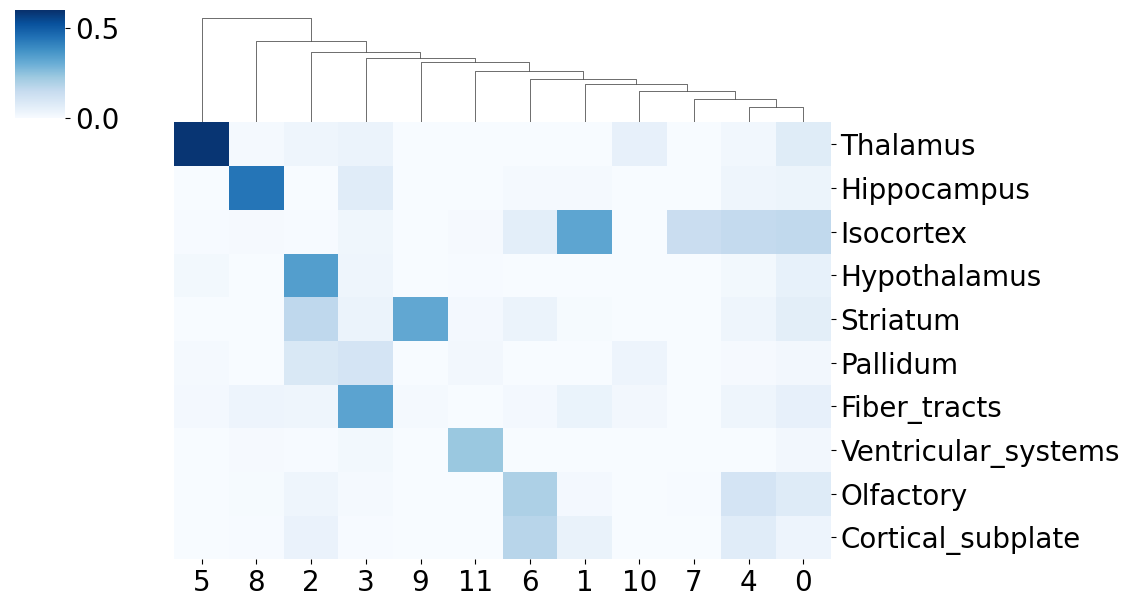

In [37]:
idx = pd.Index(
    [
        "Thalamus",
        "Hippocampus",
        "Isocortex",
        "Hypothalamus",
        "Striatum",
        "Pallidum",
        "Fiber_tracts",
        "Ventricular_systems",
        "Olfactory",
        "Cortical_subplate",
    ],
    dtype="object",
)

fs = 20
CLUSTERMAP = True
plt.figure(figsize=(10, 6))

if CLUSTERMAP:
    fig = sns.clustermap(
        data=proportions.loc[idx],
        cmap="Blues",
        row_cluster=False,
        col_cluster=True,
        annot=False,
        fmt=".2f",
        vmax=0.6,
        figsize=(10, 6),
    )
    # fig.fig.suptitle('Jaccard similarity')
    ax = fig.ax_heatmap

    ax.grid(False)
    # ax.set_xlabel('Samples')
    # ax.set_ylabel('Samples')

else:
    # Create a heatmap
    ax = sns.heatmap(
        proportions.loc[idx],
        annot=False,
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        fmt=".2%",
        annot_kws={"size": 18},
        vmin=0,  # Set minimum colorbar limit
        vmax=0.6,  # Set maximum colorbar limit
    )

# Adjust xticks and yticks fontsize
ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=fs)

# Adjust colorbar fontsize
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fs)

plt.grid(False)
# plt.savefig(f"{figure_dir}clustermap_scvi.png", bbox_inches="tight", dpi=1000)
plt.show()

In [ ]:
sc.tl.rank_genes_groups(
    adata_CD4,
    groupby="leiden_nichevi",
    method="wilcoxon",
    n_genes=1000,
    key_added="rank_genes",
    use_raw=False,
)

sc.tl.rank_genes_groups(
    adata_CD4,
    groupby="leiden_nichevi",
    method="wilcoxon",
    n_genes=1000,
    layer="corrupted_counts",
    key_added="rank_genes_corrupted",
    use_raw=False,
)